In [16]:
from numba import cuda

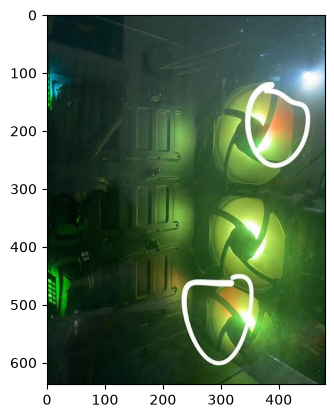

In [3]:
import matplotlib.pyplot as plt

image = plt.imread('../../image/1.jpeg')
plt.imshow(image)
h ,w ,d = image.shape

pixelSum = h * w

In [4]:
flatten = image.reshape(pixelSum,3)

0.34084177017211914


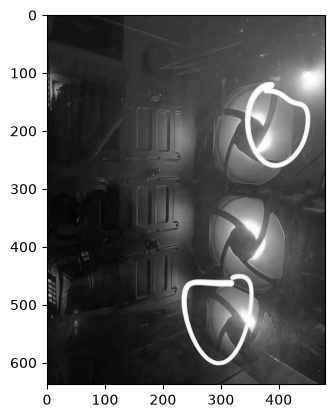

In [15]:
import numpy as np
import time 
grayCPU = np.zeros(pixelSum, np.uint8)
start = time.time()
for i in range(pixelSum):
    grayCPU[i] = np.uint8((int(flatten[i, 0]) + int(flatten[i, 1]) + int(flatten[i, 2])) / 3)
end = time.time() - start
print(end)
plt.imshow(grayCPU.reshape(h, w), cmap='gray')

0.08546805381774902


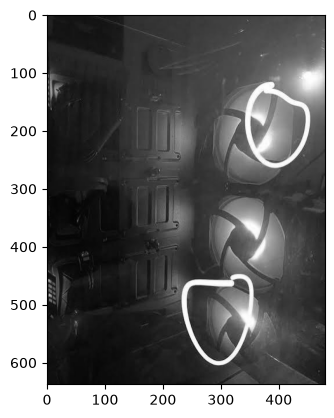

In [11]:
@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if tidx >= src.shape[0]:
        return
    g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
    dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

blockSize = 64
gridSize = (pixelSum + blockSize - 1) // blockSize
start_gpu = time.time()
devSrc = cuda.to_device(flatten)
devDst = cuda.device_array((pixelSum, 3), np.uint8)
grayscale[gridSize, blockSize](devSrc, devDst)
hostDst = devDst.copy_to_host()
end_gpu = time.time() - start_gpu
print(end_gpu)
plt.imshow(hostDst.reshape(h, w, 3))

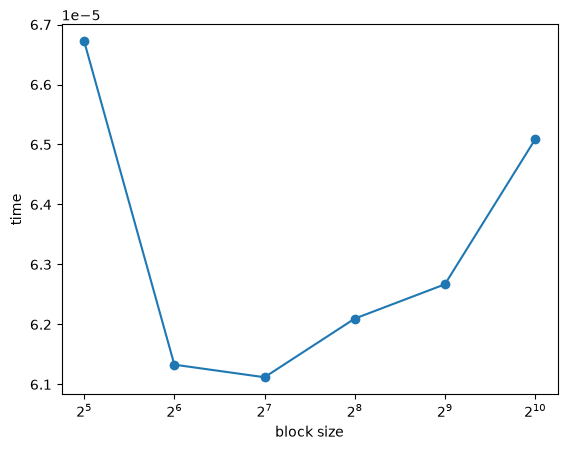

In [ ]:
blockSizes = [32, 64, 128, 256, 512, 1024]
times = []
grayscale[(pixelSum + 63) // 64, 64](devSrc, devDst) 
for blockSize in blockSizes:
    gridSize = (pixelSum + blockSize - 1) // blockSize
    start = time.time()
    for i in range(100):
        grayscale[gridSize, blockSize](devSrc, devDst)
    cuda.synchronize()
    times.append((time.time() - start) / 100)
plt.plot(blockSizes, times, marker='o')
plt.xscale('log', base=2)
plt.xlabel('block size')
plt.ylabel('time')
plt.show()
